#Quartz simulator for a sinlge 1mm slab

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from Simulate import *
from BayesianExtractor import *
from AdamExtractor import *
from data_quartz_and_si import t_r_raw as t_r, A_r
from data_quartz import A_s

In [18]:
#Global Variables

L = 2**12
deltat = (t_r[1]-t_r[0])*1e-12  # Time step from data
x_exp = A_r
true_x_exp = A_s

In [19]:
#Inintial simulation
n_init = 2
k_init = 0.01
d_init = 1e-3
layers= [(n_init - 1j*k_init, d_init)]

T_exp, y_exp = simulate_from_signal(x_exp, layers, deltat)

#Plotting
y_exp = y_exp[:L].detach().cpu().numpy()
plt.figure(figsize=(10,4))
plt.title('Time Domain of THz Pulse through single layered sample (from experimental signal).')
plt.plot(x_exp, label='Reference Pulse (Experimental)')
plt.plot(true_x_exp, label='Sample Pulse (Experimental)')
plt.plot(y_exp, label='Sample Pulse (Simulated)', color = 'black', linestyle = '--')
plt.xlim(0,2000)
plt.legend()
plt.grid()
#plt.savefig("Quartzsi plots /Quartz plot.png")
plt.show()


NameError: name 'simulate_from_signal' is not defined

In [ ]:
#Bayesian Extraction
x_exp = torch.from_numpy(A_r)
true_x_exp = torch.from_numpy(A_s)

bounds = [0.3, 0.1, 50e-6]

extractor = BayesianLayeredExtractor(reference_pulse=x_exp, 
                                     experimental_pulse=true_x_exp, 
                                     deltat=deltat, 
                                     layers_init= layers, 
                                     optimize_mask=[(True, True, True)], 
                                     optimization_bounds=bounds)

best_layers = extractor.bayesian_optimization(n_calls=40)

#Finding induvidual values
n_complex_bays, D_bays = best_layers[0]
n_bays = n_complex_bays.real
k_bays = n_complex_bays.imag

Starting Bayesian Optimization with masks...
Search Boundaries for Optimized Parameters:
Layer 1 - n ∈ (1.7, 2.3)
Layer 1 - k ∈ (-0.11, 0.09000000000000001)
Layer 1 - D ∈ (0.00095, 0.00105)


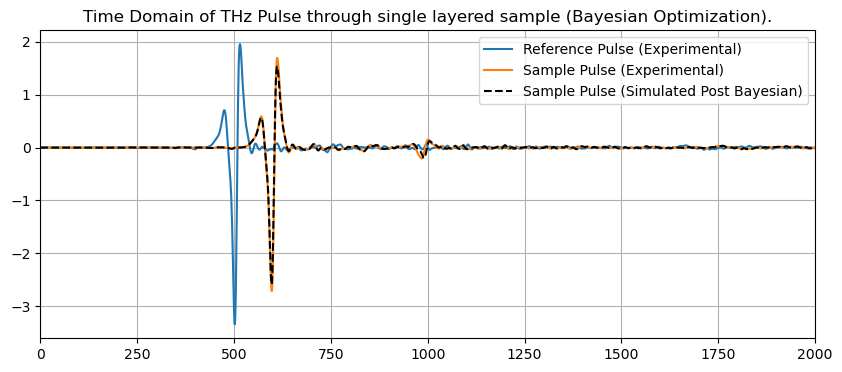

In [ ]:
#Bayesian results
T_bays, y_bays = simulate_from_signal(x_exp, best_layers, deltat)
y_bays = y_bays[:L].detach().cpu().numpy()

plt.figure(figsize=(10,4))
plt.plot(x_exp, label='Reference Pulse (Experimental)')
plt.plot(true_x_exp, label='Sample Pulse (Experimental)')
plt.plot(y_bays, label='Sample Pulse (Simulated Post Bayesian)', color = 'black', linestyle = '--')
plt.title('Time Domain of THz Pulse through single layered sample (Bayesian Optimization).')
plt.xlim(0,2000)
plt.legend()
plt.grid()
#plt.savefig("Quartzsi plots /Quartz Bayesian.png")
plt.show()

In [ ]:
#Adam Extraction post Bayesian
#Converting data into floats to work with Adam Extractor
x_exp = torch.from_numpy(A_r).float()
true_x_exp = torch.from_numpy(A_s).float()

adam_extractor = LayeredExtractor(x_exp, true_x_exp, deltat, best_layers, 
                                  optimize_mask=[(True, True, True)])

adam_best_layers = adam_extractor.optimize(num_iterations=300, 
                                           verbose=True, updates=20, alpha=1)

n_complex_adam, D_adam = adam_best_layers[0]
n_adam = n_complex_adam.real
k_adam = n_complex_adam.imag


Fine-tuning 3 parameters for 300 iterations.
Iteration 19, Loss: 1.765184e-02, Layer 0: n=1.9496, k=-0.00456, D=995.48 µm
Iteration 39, Loss: 1.454990e-02, Layer 0: n=1.9583, k=-0.00394, D=987.02 µm
Iteration 59, Loss: 1.204093e-02, Layer 0: n=1.9675, k=-0.00408, D=978.23 µm
Iteration 79, Loss: 1.117877e-02, Layer 0: n=1.9739, k=-0.00393, D=972.11 µm
Iteration 99, Loss: 1.112232e-02, Layer 0: n=1.9762, k=-0.00393, D=969.97 µm
Iteration 119, Loss: 1.112283e-02, Layer 0: n=1.9762, k=-0.00393, D=969.96 µm
Iteration 139, Loss: 1.112109e-02, Layer 0: n=1.9759, k=-0.00394, D=970.26 µm
Iteration 159, Loss: 1.112107e-02, Layer 0: n=1.9758, k=-0.00394, D=970.34 µm
Iteration 179, Loss: 1.112105e-02, Layer 0: n=1.9758, k=-0.00394, D=970.31 µm
Iteration 199, Loss: 1.112105e-02, Layer 0: n=1.9758, k=-0.00394, D=970.30 µm
Iteration 219, Loss: 1.112105e-02, Layer 0: n=1.9758, k=-0.00394, D=970.30 µm
Iteration 239, Loss: 1.112105e-02, Layer 0: n=1.9758, k=-0.00394, D=970.30 µm
Iteration 259, Loss: 1.1

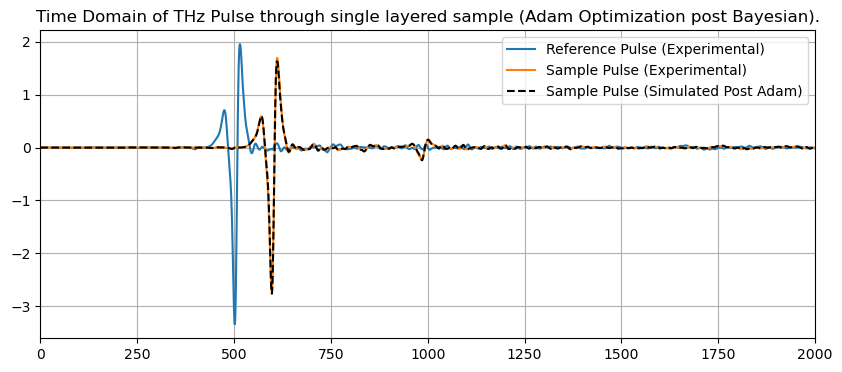

In [ ]:
# --- Adam results ---
T_adam, y_adam = simulate_from_signal(x_exp, adam_best_layers, deltat)
y_adam = y_adam[:L].detach().cpu().numpy()

plt.figure(figsize=(10,4))
plt.plot(x_exp, label='Reference Pulse (Experimental)')
plt.plot(true_x_exp, label='Sample Pulse (Experimental)') 
plt.plot(y_adam, label='Sample Pulse (Simulated Post Adam)', color = 'black', linestyle = '--') 
plt.title('Time Domain of THz Pulse through single layered sample (Adam Optimization post Bayesian).')
plt.xlim(0,2000) 
plt.legend() 
plt.grid() 
#plt.savefig("Quartzsi plots /Quartz Adam.png") 
plt.show()


In [ ]:
#Loss landscape
from loss_landscape_visualization import LossLandscapeVisualizer

# Create loss function
loss_func = create_tmm_loss_function(x_exp, true_x_exp, deltat, L)


# Define ranges
param_ranges = {
    'n': (1.6, 2.4),
    'k': (0.0, 0.12),
    'd': (0.5e-3, 2e-3)
}

# Create visualizer
viz = LossLandscapeVisualizer(loss_func, param_ranges)

# Final optimizer values
final_values = {
    'Bayesian': {'n': float(n_bays), 'k': float(k_bays), 'd': float(D_bays)},
    'ADAM': {'n': float(n_adam), 'k': float(k_adam), 'd': float(D_adam)}
}



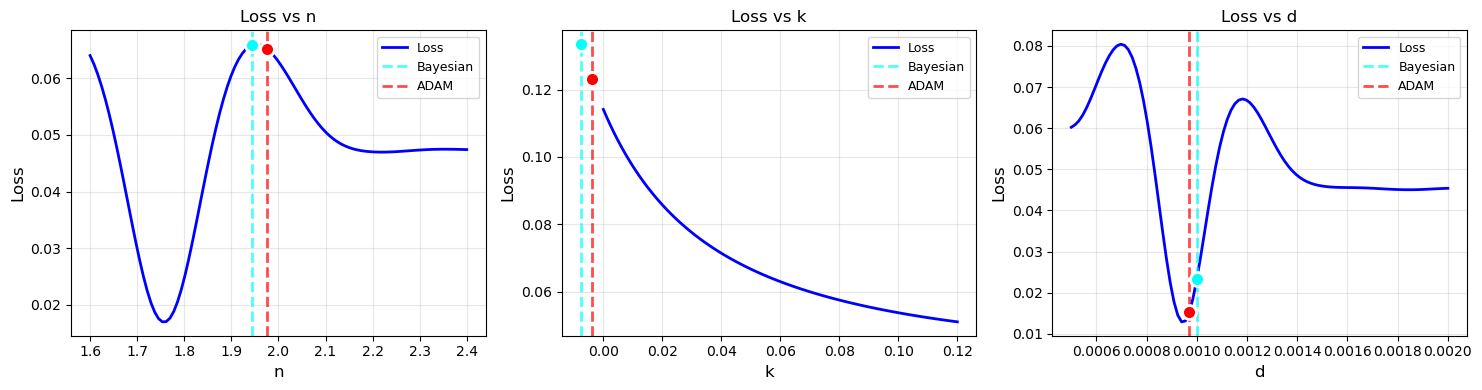

Computing loss landscape for n vs k...


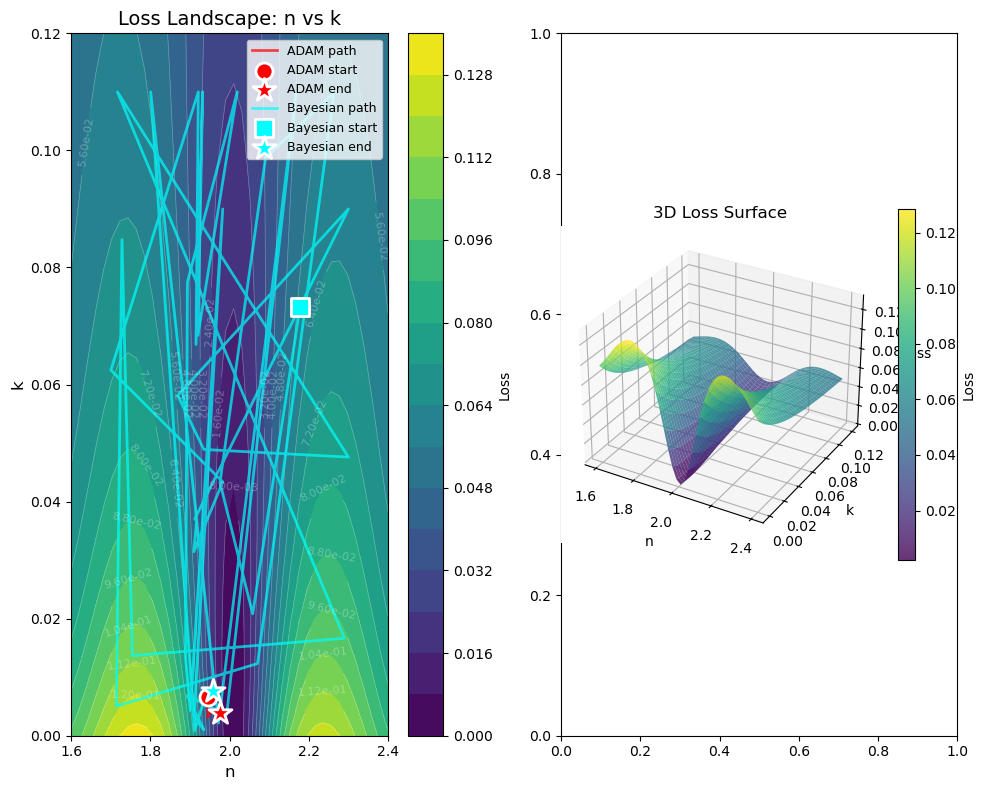

In [ ]:
#Plotting loss landscape
# 1D slices
viz.plot_1d_slices(optimizer_values=final_values)
plt.show()

# 2D landscape n vs k 
bays_path = [(p['n'][0], abs(p['k'][0])) for p in extractor.iteration_history]
adam_path = [(p['n'][0], abs(p['k'][0])) for p in adam_extractor.iteration_history]

optimzer_path = {
        'ADAM': adam_path,
        'Bayesian': bays_path
    }

# Find d at minimum loss on the 1D slice
p_min, p_max = param_ranges['d']
d_vals = np.linspace(p_min, p_max, 100)

# Use the same fixed params as the 1D slice (midpoint of n and k ranges)
fixed_nk = {
    'n': (param_ranges['n'][0] + param_ranges['n'][1]) / 2,
    'k': (param_ranges['k'][0] + param_ranges['k'][1]) / 2,
}

d_losses = [loss_func({**fixed_nk, 'd': d}) for d in d_vals]
d_fixed = float(d_vals[np.argmin(d_losses)])


viz.plot_2d_slice('n', 'k', 
                  fixed_params={'d': d_fixed},
                  optimizer_paths=optimzer_path,
                  resolution=40)
plt.show()

# Local minima test
#viz.analyze_local_minima(final_values, n_samples=2000)



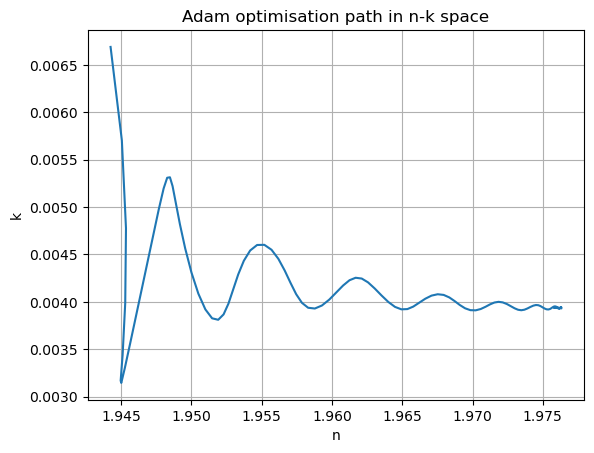

In [ ]:
#Zoom in on optimizer path of ADAM
adam_n = [adam_path[i][0] for i in range(len(adam_path))]
adam_k = [adam_path[i][1] for i in range(len(adam_path))]

plt.plot(adam_n, adam_k, '-', label='ADAM Path')
plt.title('Adam optimisation path in n-k space')
plt.xlabel('n')
plt.ylabel('k')
plt.grid()
plt.show()

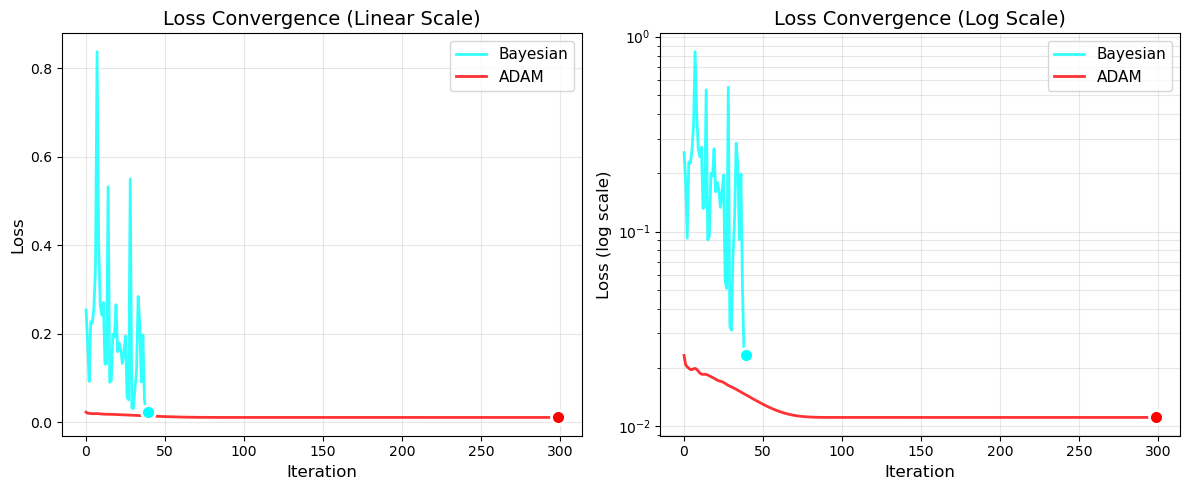

In [ ]:
#Optimser convergence
optimizer_histories = {
    'Bayesian': extractor.loss_history,
    'ADAM': adam_extractor.loss_history
}

fig3, _ = viz.plot_convergence_comparison(optimizer_histories)
plt.show()

In [ ]:
#Printing the results
print("-------------------------------- RESULTS --------------------------------")
print("Initital values:")
print("layer 1: n = 2, k = 0.01, d = 1e-3")
print()
print("Bayesian Optimization Results: n =", np.round(n_bays, 3), "k =", np.round(k_bays, 5), "d =", np.round(D_bays, 6))
print()
print("Adam Optimization Results: n =", np.round(n_adam, 3), "k =", np.round(k_adam, 5), "d =", np.round(D_adam, 6))
print("------------------------------------------------------------------------")   

-------------------------------- RESULTS --------------------------------
Initital values:
layer 1: n = 2, k = 0.01, d = 1e-3

Bayesian Optimization Results: n = 1.943 k = -0.00769 d = 0.001

Adam Optimization Results: n = 1.976 k = -0.00394 d = 0.00097
------------------------------------------------------------------------
